In [69]:
import numpy as np
import scipy.io as sio
import vtk
from scipy.interpolate import interp1d
from vtk.util.numpy_support import numpy_to_vtk
from renderizer import EGMRenderer
import os
import cv2
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..", "Code")))
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt


In [70]:
def corr_spearman_cols(array1, array2):
    """
    Calcula la correlación de Spearman entre las columnas de dos arrays.

    Args:
        array1: un array de numpy de dimensión (n,m)
        array2: otro array de numpy de dimensión (n,m)

    Returns:
        Un array de numpy de dimensión (m,) que contiene la correlación de Spearman
        de las columnas de array1 y array2.
    """

    # Verificar si ambos arrays tienen las mismas dimensiones
    assert (
        array1.shape == array2.shape
    ), "Los arrays deben tener las mismas dimensiones."

    # Calcular la correlación de Spearman de las columnas de ambos arrays
    n_cols = array1.shape[1]
    corr = np.zeros(n_cols)
    for i in range(n_cols):
        corr[i], _ = spearmanr(array1[:, i], array2[:, i])

    return corr

In [71]:
# Cargar datos
#model_path = "/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/OMAMI_weighted/reconstructions_by_model_OMAMI_weighted.mat"
model_path="/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/pruebas interpol/reconstructions_by_model_pruebas interpol.mat"
model_path="/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/OMAMI_bs_200_2048_norm/reconstructions_by_model_OMAMI_bs_200_2048_norm.mat"
geom_path_CF = "/home/pdi/miriamgf/tesis/Autoencoders/geometries/Atria_geom/Modelos_computacionales_Carlos_Fambuena/Atria.mat"
geom_path_edgar= "/home/pdi/miriamgf/tesis/Autoencoders/geometries/Atria_geom/Modelos_Edgar/Atria.mat"
model_path_database= "/home/pdi/miriamgf/tesis/Autoencoders/Data/modelLA_RSPV_CAF_150115/EGMs.mat"
output_directory = "/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200"
path_tikhonov="/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/scripts/Tikhonov/figures/tikhonov_matlab.mat"
os.makedirs(output_directory, exist_ok=True)

tikhonov = False

# Cargar datos del modelo y la geometría
model_name="modelLA_PLAW_140711_arm"
try:
    model = sio.loadmat(model_path)[model_name]
    print('Loaded model ', model_name)
except:
    model = sio.loadmat(model_path)

try:
    geom = sio.loadmat(geom_path_CF)["geometries"]
except:
    geom = sio.loadmat(geom_path_CF)

Loaded model  modelLA_PLAW_140711_arm


In [72]:
# Extraer datos
y_reconstructed = model["reconstruction"][0,0]
y_label = model["label"][0,0]
heart = geom["heart"]
faces = heart["faces"][0, 0] - 1  # Convertir a índice base 0
vertices = heart["vertices"][0, 0]

In [73]:
y_reconstructed.shape

(4000, 2048)

## Mapas de correlación

In [74]:
corr=corr_spearman_cols(y_reconstructed, y_label)
y_reconstructed=corr
y_label=corr


In [75]:
corr

array([-0.38859493, -0.58892874, -0.44545189, ...,  0.32041214,
        0.20297469,  0.17539694])

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png


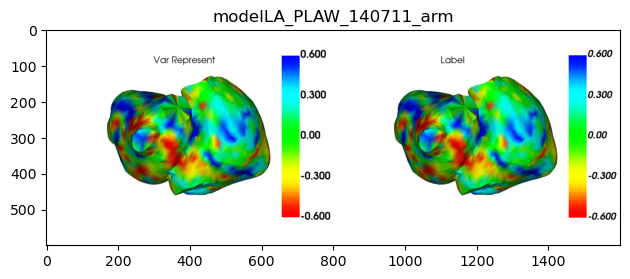

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
modelLA_PLAW_140711_arm
Video guardado en /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/video23.avi


In [82]:
# Crear renderizadores para var_represent y var_represent_original
renderer_var = EGMRenderer(faces, vertices, min_val=-0.6, max_val=0.6)
try:
    renderer_label = EGMRenderer(faces, vertices,  min_val=-0.6, max_val=0.6)
except:
    y_label=y_label[0][0]
    renderer_label = EGMRenderer(faces, vertices,  min_val=-0.6, max_val=0.6)


#y_label=y_reconstructed 

#y_reconstructed = renderer_var.smoothing_plot(10, y_reconstructed)
#ylabel = renderer_label.smoothing_plot(10, y_label)

#probaf normalizacion
# Inicializa una matriz para las señales estandarizadas

estandarizar=False
normalizar=False

if estandarizar:
    y_label_std = np.zeros_like(y_label)
    for nodo in range(y_label.shape[1]): 
        mean_val = np.mean(y_label[:, nodo])  
        std_val = np.std(y_label[:, nodo])    
        if std_val != 0:  
            y_label_std[:, nodo] = (y_label[:, nodo] - mean_val) / std_val
        else:
            y_label_std[:, nodo] = 0  
    var_represent=y_reconstructed
    var_represent_original=y_label_std


if normalizar:
    y_label_n = np.zeros_like(y_label)
    for nodo in range(y_label.shape[1]):  
        min_val = np.min(y_label[:, nodo])
        max_val = np.max(y_label[:, nodo])
        
        if max_val != min_val:  
            y_label_n[:, nodo] = (y_label[:, nodo] - min_val) / (max_val - min_val)
        else:
            y_label_n[:, nodo] = 0  

    var_represent = y_reconstructed
    var_represent_original = y_label_n

var_represent=y_reconstructed
var_represent_original=y_label



'''
if var_represent.shape[1]!=2048:
    var_represent=var_represent[0][0]
    var_represent_original=var_represent_original[0][0]
'''
# Configurar renderizadores como subplots
renderer_var.renderer.SetViewport(0.0, 0.0, 0.5, 1.0)  # Subplot izquierdo
renderer_label.renderer.SetViewport(0.5, 0.0, 1.0, 1.0)  # Subplot derecho

# Configurar fondo blanco
renderer_var.renderer.SetBackground(1, 1, 1)  # Gris claro
renderer_label.renderer.SetBackground(1, 1, 1)  # Gris claro


# Create a text actor for var_represent
title_var = vtk.vtkTextActor()
title_var.SetInput("Var Represent")
title_varprop = title_var.GetTextProperty()
title_varprop.SetFontFamilyToArial()
title_varprop.SetFontSize(25)
#title_varprop.BoldOn()
title_varprop.SetColor(0, 0, 0)  # Black color
title_var.SetPosition(300, 500)  # Adjust position manually as needed
renderer_var.renderer.AddActor2D(title_var)

# Create a text actor for label
title_label = vtk.vtkTextActor()
title_label.SetInput("Label")
title_labelprop = title_label.GetTextProperty()
title_labelprop.SetFontFamilyToArial()
title_labelprop.SetFontSize(25)
#title_labelprop.BoldOn()
title_labelprop.SetColor(0, 0, 0)  # Black color
title_label.SetPosition(300, 500)  # Adjust position manually as needed

# Add the titles to the renderers

renderer_label.renderer.AddActor2D(title_label)

# Scalar bars remain unchanged but without titles
scalar_bar_var = vtk.vtkScalarBarActor()
scalar_bar_var.SetLookupTable(renderer_var.mapper.GetLookupTable())
scalar_bar_var.GetLabelTextProperty().SetColor(0, 0, 0)  # Set font color to black
scalar_bar_var.GetLabelTextProperty().SetItalic(False)  # Ensure text is not italicized
scalar_bar_var.GetLabelTextProperty().SetShadow(False) 
scalar_bar_var.GetLabelTextProperty().SetFontFamilyToArial()  # Set font to Arial
scalar_bar_var.GetLabelTextProperty().SetFontSize(15) 
scalar_bar_var.SetNumberOfLabels(5)

scalar_bar_label = vtk.vtkScalarBarActor()
scalar_bar_label.SetLookupTable(renderer_label.mapper.GetLookupTable())
scalar_bar_label.GetLabelTextProperty().SetColor(0, 0, 0)  # Set font color to black
scalar_bar_label.SetNumberOfLabels(5)

renderer_var.renderer.AddActor2D(scalar_bar_var)
renderer_label.renderer.AddActor2D(scalar_bar_label)


# Configurar la ventana de renderizado conjunta
render_window = vtk.vtkRenderWindow()
render_window.SetSize(1600, 600)  # Tamaño total de la ventana
render_window.AddRenderer(renderer_var.renderer)
render_window.AddRenderer(renderer_label.renderer)

# Configurar la cámara para ambos subplots
center = renderer_var.mesh.GetCenter()
for renderer in [renderer_var, renderer_label]:
    renderer.camera.SetPosition(center[0], center[1], center[2] + 35)  # Alejar la cámara
    renderer.camera.SetFocalPoint(center[0], center[1], center[2])  # Enfocar al centro
    renderer.camera.SetViewUp(1, 0, 0)  # Eje vertical hacia arriba
    renderer.camera.Elevation(270)  # Flip de 180 grados sobre el eje horizontal
    renderer.camera.Azimuth(0)  # Rotar 0 grados en azimut
    renderer.renderer.ResetCameraClippingRange()

# Configurar el filtro para capturar imágenes
window_to_image_filter = vtk.vtkWindowToImageFilter()
window_to_image_filter.SetInput(render_window)

#configure video
output_video = os.path.join(output_directory, f"video23.avi")
sample_frame = os.path.join(output_directory, "sample_frame.png")
try:
    renderer.render_frame(var_represent[0, :], sample_frame)
except:
    renderer.render_frame(var_represent[:], sample_frame)

framei = cv2.imread(sample_frame)
height, width, layers = framei.shape
fps = 10  # Frames por segundo
fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Codec para AVI
video = cv2.VideoWriter(output_video, fourcc, fps, (1600, 600))

# Iterar sobre instantes y generar frames
for instant in range(0, 1, 1):  # Cada 500 instantes
    # Actualizar los datos escalares de los dos renderizadores
    try:
        vtk_scalars_var = numpy_to_vtk(var_represent[instant, :], deep=True)
    except:
        vtk_scalars_var = numpy_to_vtk(var_represent[:], deep=True)

    try:
        vtk_scalars_label = numpy_to_vtk(var_represent_original[instant, :], deep=True)

    except:
        vtk_scalars_label = numpy_to_vtk(var_represent_original[:], deep=True)
    renderer_var.mesh.GetPointData().SetScalars(vtk_scalars_var)
    renderer_label.mesh.GetPointData().SetScalars(vtk_scalars_label)

    renderer_var.mesh.Modified()
    renderer_label.mesh.Modified()

    # Renderizar la ventana con subplots
    render_window.Render()

    # Guardar la imagen como PNG
    window_to_image_filter.Modified()
    window_to_image_filter.Update()

    output_file = os.path.join(output_directory, f"frame_{instant:04d}.png")
    writer = vtk.vtkPNGWriter()
    writer.SetFileName(output_file)
    writer.SetInputData(window_to_image_filter.GetOutput())
    writer.Write()

    # Obtener la imagen como un array numpy
    image_data = window_to_image_filter.GetOutput()
    dims = image_data.GetDimensions()
    vtk_array = vtk.util.numpy_support.vtk_to_numpy(image_data.GetPointData().GetScalars())
    frame = vtk_array.reshape((dims[1], dims[0], 3))[::-1]  # Invertir eje Y

    # Escribir el frame en el video
    #video.write(frame)

    print(f"Frame guardado: {output_file}")
    #os.remove(output_file)

    plt.figure()
    plt.imshow(frame)
    plt.title(model_name)

    plt.tight_layout()
    plt.show()

    print(f"Frame guardado: {output_file}")
    print(model_name)

# Liberar el objeto VideoWriter
#video.release()

print(f"Video guardado en {output_video}")

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png


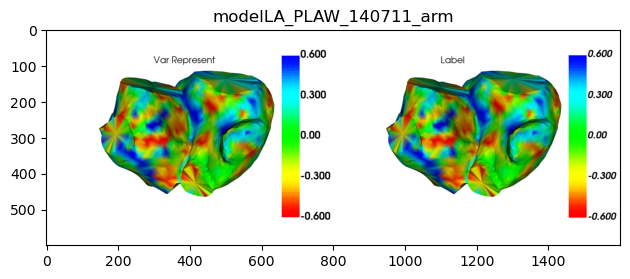

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
modelLA_PLAW_140711_arm
Video guardado en /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/video23.avi


In [81]:
# Crear renderizadores para var_represent y var_represent_original
renderer_var = EGMRenderer(faces, vertices, min_val=-0.6, max_val=0.6)
try:
    renderer_label = EGMRenderer(faces, vertices,  min_val=-0.6, max_val=0.6)
except:
    y_label=y_label[0][0]
    renderer_label = EGMRenderer(faces, vertices,  min_val=-0.6, max_val=0.6)


#y_label=y_reconstructed 

#y_reconstructed = renderer_var.smoothing_plot(10, y_reconstructed)
#ylabel = renderer_label.smoothing_plot(10, y_label)

#probaf normalizacion
# Inicializa una matriz para las señales estandarizadas

estandarizar=False
normalizar=False

if estandarizar:
    y_label_std = np.zeros_like(y_label)
    for nodo in range(y_label.shape[1]): 
        mean_val = np.mean(y_label[:, nodo])  
        std_val = np.std(y_label[:, nodo])    
        if std_val != 0:  
            y_label_std[:, nodo] = (y_label[:, nodo] - mean_val) / std_val
        else:
            y_label_std[:, nodo] = 0  
    var_represent=y_reconstructed
    var_represent_original=y_label_std


if normalizar:
    y_label_n = np.zeros_like(y_label)
    for nodo in range(y_label.shape[1]):  
        min_val = np.min(y_label[:, nodo])
        max_val = np.max(y_label[:, nodo])
        
        if max_val != min_val:  
            y_label_n[:, nodo] = (y_label[:, nodo] - min_val) / (max_val - min_val)
        else:
            y_label_n[:, nodo] = 0  

    var_represent = y_reconstructed
    var_represent_original = y_label_n

var_represent=y_reconstructed
var_represent_original=y_label



'''
if var_represent.shape[1]!=2048:
    var_represent=var_represent[0][0]
    var_represent_original=var_represent_original[0][0]
'''
# Configurar renderizadores como subplots
renderer_var.renderer.SetViewport(0.0, 0.0, 0.5, 1.0)  # Subplot izquierdo
renderer_label.renderer.SetViewport(0.5, 0.0, 1.0, 1.0)  # Subplot derecho

# Configurar fondo blanco
renderer_var.renderer.SetBackground(1, 1, 1)  # Gris claro
renderer_label.renderer.SetBackground(1, 1, 1)  # Gris claro


# Create a text actor for var_represent
title_var = vtk.vtkTextActor()
title_var.SetInput("Var Represent")
title_varprop = title_var.GetTextProperty()
title_varprop.SetFontFamilyToArial()
title_varprop.SetFontSize(25)
#title_varprop.BoldOn()
title_varprop.SetColor(0, 0, 0)  # Black color
title_var.SetPosition(300, 500)  # Adjust position manually as needed
renderer_var.renderer.AddActor2D(title_var)

# Create a text actor for label
title_label = vtk.vtkTextActor()
title_label.SetInput("Label")
title_labelprop = title_label.GetTextProperty()
title_labelprop.SetFontFamilyToArial()
title_labelprop.SetFontSize(25)
#title_labelprop.BoldOn()
title_labelprop.SetColor(0, 0, 0)  # Black color
title_label.SetPosition(300, 500)  # Adjust position manually as needed

# Add the titles to the renderers

renderer_label.renderer.AddActor2D(title_label)

# Scalar bars remain unchanged but without titles
scalar_bar_var = vtk.vtkScalarBarActor()
scalar_bar_var.SetLookupTable(renderer_var.mapper.GetLookupTable())
scalar_bar_var.GetLabelTextProperty().SetColor(0, 0, 0)  # Set font color to black
scalar_bar_var.GetLabelTextProperty().SetItalic(False)  # Ensure text is not italicized
scalar_bar_var.GetLabelTextProperty().SetShadow(False) 
scalar_bar_var.GetLabelTextProperty().SetFontFamilyToArial()  # Set font to Arial
scalar_bar_var.GetLabelTextProperty().SetFontSize(15) 
scalar_bar_var.SetNumberOfLabels(5)

scalar_bar_label = vtk.vtkScalarBarActor()
scalar_bar_label.SetLookupTable(renderer_label.mapper.GetLookupTable())
scalar_bar_label.GetLabelTextProperty().SetColor(0, 0, 0)  # Set font color to black
scalar_bar_label.SetNumberOfLabels(5)

renderer_var.renderer.AddActor2D(scalar_bar_var)
renderer_label.renderer.AddActor2D(scalar_bar_label)


# Configurar la ventana de renderizado conjunta
render_window = vtk.vtkRenderWindow()
render_window.SetSize(1600, 600)  # Tamaño total de la ventana
render_window.AddRenderer(renderer_var.renderer)
render_window.AddRenderer(renderer_label.renderer)

# Configurar la cámara para ambos subplots
center = renderer_var.mesh.GetCenter()

for renderer in [renderer_var, renderer_label]:

    renderer.camera.SetPosition(center[0], center[1], center[2] + 35)  # Alejar la cámara
    renderer.camera.SetFocalPoint(center[0], center[1], center[2])  # Enfocar al centro
    renderer.camera.SetViewUp(1, 0, 0)  # Eje vertical hacia arriba
    renderer.camera.Elevation(30)  # Flip de 180 grados sobre el eje horizontal
    renderer.camera.Azimuth(0)  # Rotar 0 grados en azimut
    renderer.renderer.ResetCameraClippingRange()

# Configurar el filtro para capturar imágenes
window_to_image_filter = vtk.vtkWindowToImageFilter()
window_to_image_filter.SetInput(render_window)

#configure video
output_video = os.path.join(output_directory, f"video23.avi")
sample_frame = os.path.join(output_directory, "sample_frame.png")
try:
    renderer.render_frame(var_represent[0, :], sample_frame)
except:
    renderer.render_frame(var_represent[:], sample_frame)
framei = cv2.imread(sample_frame)
height, width, layers = framei.shape
fps = 10  # Frames por segundo
fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Codec para AVI
video = cv2.VideoWriter(output_video, fourcc, fps, (1600, 600))

# Iterar sobre instantes y generar frames
for instant in range(0, 1, 1):  # Cada 500 instantes
    # Actualizar los datos escalares de los dos renderizadores
    try:
        vtk_scalars_var = numpy_to_vtk(var_represent[instant, :], deep=True)
        vtk_scalars_label = numpy_to_vtk(var_represent_original[instant, :], deep=True)
    except: 
        vtk_scalars_var = numpy_to_vtk(var_represent[:], deep=True)
        vtk_scalars_label = numpy_to_vtk(var_represent_original[:], deep=True)

    renderer_var.mesh.GetPointData().SetScalars(vtk_scalars_var)
    renderer_label.mesh.GetPointData().SetScalars(vtk_scalars_label)

    renderer_var.mesh.Modified()
    renderer_label.mesh.Modified()

    # Renderizar la ventana con subplots
    render_window.Render()

    # Guardar la imagen como PNG
    window_to_image_filter.Modified()
    window_to_image_filter.Update()

    output_file = os.path.join(output_directory, f"frame_{instant:04d}.png")
    writer = vtk.vtkPNGWriter()
    writer.SetFileName(output_file)
    writer.SetInputData(window_to_image_filter.GetOutput())
    writer.Write()

    # Obtener la imagen como un array numpy
    image_data = window_to_image_filter.GetOutput()
    dims = image_data.GetDimensions()
    vtk_array = vtk.util.numpy_support.vtk_to_numpy(image_data.GetPointData().GetScalars())
    frame = vtk_array.reshape((dims[1], dims[0], 3))[::-1]  # Invertir eje Y

    # Escribir el frame en el video
    #video.write(frame)

    print(f"Frame guardado: {output_file}")
    #os.remove(output_file)

    plt.figure()
    plt.imshow(frame)
    plt.title(model_name)

    plt.tight_layout()
    plt.show()

    print(f"Frame guardado: {output_file}")
    print(model_name)

# Liberar el objeto VideoWriter
#video.release()

print(f"Video guardado en {output_video}")